# MQ03 — GPT-1 Pre-Training (Decoder-only)
기존 **Encoder-Decoder Transformer** 구조를, GPT-1 논문(*Improving Language Understanding by Generative Pre-Training*, Radford et al., 2018)의 **Decoder-only 생성 모델**로 재구성합니다.

> 본 과제는 **프리트레이닝(다음에 올 토큰 예측)** 과 생성 동작 확인에 초점을 둡니다.  
> (파인튜닝·높은 대화 품질은 평가 범위 밖)

---

## [평가 1] Transformer 대비 변경할 부분 (블록별 설명)

| 블록 | Transformer (원본) | GPT-1 (본 프로젝트) | 변경 이유 |
|------|---------------------|--------------|-----------|
| **전체 구조** | Encoder + Decoder Seq2Seq | **Decoder stack만** | GPT는 단방향 LM — Encoder/Cross-Attn 불필요 |
| **Encoder 블록** | Self-Attn + FFN | **삭제** | 질문만 인코딩하는 경로가 없음 |
| **Decoder 블록** | Masked Self-Attn → **Cross-Attn** → FFN | Masked Self-Attn → FFN (**Cross-Attn 제거**) | Encoder 출력이 없으므로 cross-attention 제거 |
| **입력 블록** | Token Emb + **sin/cos PE** | Token Emb + **학습 가능한 Position Embedding** | GPT-1 논문: *learned positional embeddings* |
| **학습 목표** | Q→A Teacher Forcing (분리 입력) | **단일 시퀀스 next-token LM** | 디코더 기반 생성 · pre-training |
| **마스크** | enc / dec-enc / dec(lookahead) | **causal + padding만** | 자기회귀(미래 토큰 차단)만 필요 |
| **생성** | Beam(질문 인코딩 후 디코딩) | **프롬프트 이어쓰기(autoregressive)** | Decoder-only 추론 |

코드 셀에도 `GPT 변경:` 주석으로 동일 내용을 표시했습니다.

```mermaid
flowchart LR
  subgraph TF[Transformer]
    E[Encoder] --> D[Decoder+CrossAttn]
  end
  subgraph GPT[MQ03 GPT-1]
    B[Token+Pos Embedding] --> G[Decoder Blocks x N]
    G --> H[LM Head]
  end
  TF -.->|제거 Encoder/CrossAttn<br/>입력·학습목표 변경| GPT
```


## Step 0. 환경 초기화


In [1]:
# ================================================================================
# 🎯 [Step 0. 환경 초기화 및 전역 상수]
# - 목적: 재현 가능한 실험 환경 + Decoder-only LM 프리트레이닝용 상수 선언
# - GPT 변경: Seq2Seq용 BEAM/증강/BLEU 상수는 사용하지 않음
# ================================================================================
import math
import random
import re
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt  # Step 6 loss 곡선
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# === 데이터·실험 상수 ===
SEED = 42
MAX_LEN = 64          # Q+SEP+A를 한 시퀀스로 묶을 때 상한 (짧으면 샘플 다수 drop)
MIN_TOKEN_LEN = 2     # 질문 최소 형태소 수
MIN_ANSWER_LEN = 2    # 답변 최소 형태소 수
MAX_ANSWER_FREQ = 40  # 동일 답변 과다 등장 시 다운샘플 상한 (만능답 편향 완화)
VAL_RATIO = 0.1       # hold-out 검증 비율
LABEL_SMOOTHING = 0.1 # CE soft target → 과신(overconfidence) 완화

# 1) 난수 시드 동기화 → 재현성 (재학습 간 생성 품질 흔들림 완화)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# DataLoader worker/shuffle용 제너레이터 (Step 6에서 사용)
g_cpu = torch.Generator()
g_cpu.manual_seed(SEED)

# 2) 디바이스: Mac MPS → CUDA → CPU
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

# 3) 경로: CSV·체크포인트 저장 위치
DATA_DIR = Path("./data")
CHATBOT_DIR = DATA_DIR / "chatbot"
CHATBOT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHATBOT_DIR / "gpt1_best.pt"  # val 가중 loss 최저 시점 저장

print("torch:", torch.__version__)
print("device:", device)
print(f"SEED={SEED}")


torch: 2.8.0
device: mps
SEED=42


/Users/choiseunghyeon/pytorch-env/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1. 데이터 다운로드
`songys/Chatbot_data`의 한국어 Q/A 쌍 CSV를 사용합니다.
로컬에 없으면 GitHub raw URL에서 다운로드합니다.


In [2]:
# ================================================================================
# 🎯 [Step 1. ChatbotData.csv 확보]
# - 목적: 원본 Q/A 코퍼스를 로컬에 준비
# - 이슈: 구 URL(ChatbotData%20.csv)은 404 → ChatbotData.csv 로 수정
# ================================================================================
CHATBOT_CSV = CHATBOT_DIR / "ChatbotData.csv"
CHATBOT_URL = (
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"
)

# 없으면 원격 다운로드 (있으면 스킵)
if not CHATBOT_CSV.exists():
    print("ChatbotData.csv 다운로드 중...")
    urllib.request.urlretrieve(CHATBOT_URL, CHATBOT_CSV)

df = pd.read_csv(CHATBOT_CSV)
questions = df["Q"].astype(str).tolist()
answers = df["A"].astype(str).tolist()
print("총 문장 쌍:", len(questions))
print("예) Q:", questions[0], "| A:", answers[0])


총 문장 쌍: 11823
예) Q: 12시 땡! | A: 하루가 또 가네요.


## Step 2. 전처리 + Decoder-only 학습용 포맷
### [평가 2] 모델 입력 형식에 맞는 전처리

GPT는 **한 줄짜리 자기회귀 생성 모델**이므로 Q/A를 아래처럼 하나의 시퀀스로 만듭니다.

`<start> + Question + <sep> + Answer + <end>`

**9차:** 형태소 분석기를 Kiwi → **PeCab** 으로 교체 (분절 품질 튜닝).  
GPT-1 구조는 그대로이며, 토크나이저만 바꾼다.


In [3]:
# ================================================================================
# 🎯 [Step 2. 정제 + GPT용 LM 시퀀스 구성]
# GPT 변경: enc/dec 분리가 아니라 단일 시퀀스
#   <start> + Q_tokens + <sep> + A_tokens + <end>
#
# 전처리 개선 이력:
#   1) 길이 초과 시 drop → 질문 truncate로 답변 보존
#   2) 동일 답변 빈도 cap → 만능 답 과적합 완화
#   3) 빈/짧은 문장 필터
#   4) [9차] Kiwi → PeCab 형태소 (조각 토큰/어미 과분절 완화)
# ================================================================================

def preprocess_sentence(sentence: str) -> str:
    """
    [문장 정제]
    - lower → 허용 문자만 유지 → 연속 공백 압축
    """
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"[^a-z0-9\uAC00-\uD7A3\s.,!?]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()


questions = [preprocess_sentence(q) for q in questions]
answers = [preprocess_sentence(a) for a in answers]

from collections import Counter

# ------------------------------------------------------------
# [9차] 형태소 분석기 선택
# - kiwi: 기존 (어미를 과도 분절 → 'ᆯ' 같은 조각 토큰 발생)
# - pecab: 순수 Python 형태소 분석기 (아리랑/MeCab 대안, JVM 불필요)
#   예) kiwi: 잘/하/ᆯ/수/...  vs  pecab: 잘/할/수/...
# GPT-1 아키텍처와 무관 — 전처리만 교체
# ------------------------------------------------------------
TOKENIZER_NAME = "pecab"  # "pecab" | "kiwi"

if TOKENIZER_NAME == "pecab":
    from pecab import PeCab
    _tagger = PeCab()

    def morphs(text: str):
        """PeCab 형태소 표층형. 공백 토큰 제거."""
        return [t for t in _tagger.morphs(text) if t and t.strip()]

elif TOKENIZER_NAME == "kiwi":
    from kiwipiepy import Kiwi
    _tagger = Kiwi()

    def morphs(text: str):
        return [t.form for t in _tagger.tokenize(text) if t.form.strip()]

else:
    raise ValueError(f"Unknown TOKENIZER_NAME: {TOKENIZER_NAME}")

print(f"tokenizer: {TOKENIZER_NAME}")
# 분절 품질 빠른 비교 로그
_demo = "잘 할 수 있을 거예요 / 오늘 기분이 어때요? / 배고파요"
print("demo:", _demo)
print("morphs:", morphs(_demo.replace(" / ", " ")))


# 특수 토큰 ID (vocab 앞부분 고정)
PAD_ID, START_ID, END_ID, UNK_ID, SEP_ID = 0, 1, 2, 3, 4
SPECIAL = {
    "<pad>": PAD_ID,
    "<start>": START_ID,
    "<end>": END_ID,
    "<unk>": UNK_ID,
    "<sep>": SEP_ID,  # GPT 변경: 질문/답변 경계 토큰
}


def _fit_to_max_len(q_tok, a_tok, max_len=MAX_LEN):
    """
    [<start>]+Q+[<sep>]+A+[<end>] 가 max_len을 넘으면
    ★ 질문(Q)만 앞에서 잘라 길이를 맞춤. 답변은 최대한 보존.
    (초기에 긴 샘플을 전부 drop 하면 데이터 손실이 커서 개선)
    """
    overhead = 3  # start, sep, end
    max_content = max_len - overhead
    if len(a_tok) > max_content - MIN_TOKEN_LEN:
        a_tok = a_tok[: max_content - MIN_TOKEN_LEN]
    q_budget = max_content - len(a_tok)
    if q_budget < MIN_TOKEN_LEN:
        return None
    if len(q_tok) > q_budget:
        q_tok = q_tok[:q_budget]
    return q_tok, a_tok


def build_lm_corpus(qs, ans):
    """
    [GPT Pre-training 코퍼스 빌더]
    1) 형태소 토큰화
    2) (Q,A) 완전 동일 쌍만 중복 제거
    3) 동일 답변 빈도 ≤ MAX_ANSWER_FREQ 로 다운샘플
    4) 길이 맞춤 (_fit_to_max_len)
    """
    pairs = []
    seen_qa = set()
    skipped = {"short": 0, "dup": 0, "fit": 0}

    # mininterval: 노트북 저장 시 tqdm 줄 스팸 완화
    for q, a in tqdm(zip(qs, ans), total=len(qs), desc="tokenize", mininterval=2.0, maxinterval=10.0):
        if not q or not a:
            skipped["short"] += 1
            continue
        q_tok = morphs(q)
        a_tok = morphs(a)
        if len(q_tok) < MIN_TOKEN_LEN or len(a_tok) < MIN_ANSWER_LEN:
            skipped["short"] += 1
            continue

        fitted = _fit_to_max_len(q_tok, a_tok, MAX_LEN)
        if fitted is None:
            skipped["fit"] += 1
            continue
        q_tok, a_tok = fitted

        qa_key = (tuple(q_tok), tuple(a_tok))
        if qa_key in seen_qa:
            skipped["dup"] += 1
            continue
        seen_qa.add(qa_key)
        pairs.append((q_tok, a_tok))

    # --- 동일 답변 빈도 cap (셔플 후 선착순으로 상한까지 채택) ---
    kept, dropped_freq = [], 0
    ans_kept = Counter()
    rng = random.Random(SEED)
    order = list(range(len(pairs)))
    rng.shuffle(order)
    for i in order:
        q_tok, a_tok = pairs[i]
        key = tuple(a_tok)
        if ans_kept[key] >= MAX_ANSWER_FREQ:
            dropped_freq += 1
            continue
        ans_kept[key] += 1
        kept.append((q_tok, a_tok))

    corpus = [
        ["<start>"] + q_tok + ["<sep>"] + a_tok + ["<end>"]
        for q_tok, a_tok in kept
    ]

    print(
        f"LM 샘플: {len(corpus)} "
        f"(skip short={skipped['short']}, dup={skipped['dup']}, fit={skipped['fit']}, "
        f"freq_cap={dropped_freq})"
    )
    print("예시:", corpus[0])
    top_ans = Counter(tuple(a) for _, a in kept).most_common(5)
    print("답변 빈도 TOP5:")
    for toks, cnt in top_ans:
        print(f"  {cnt:4d} | {' '.join(toks)}")
    return corpus


lm_corpus = build_lm_corpus(questions, answers)

# train / val 분리 (인덱스 셔플)
n = len(lm_corpus)
idx = np.arange(n)
np.random.seed(SEED)
np.random.shuffle(idx)
val_n = max(1, int(n * VAL_RATIO))
val_set = set(idx[:val_n].tolist())
train_seqs = [lm_corpus[i] for i in range(n) if i not in val_set]
val_seqs = [lm_corpus[i] for i in range(n) if i in val_set]
print(f"train: {len(train_seqs)} | val: {len(val_seqs)}")


tokenizer: pecab
demo: 잘 할 수 있을 거예요 / 오늘 기분이 어때요? / 배고파요
morphs: ['잘', '할', '수', '있', '을', '거', '예요', '오늘', '기분', '이', '어때요', '?', '배고파요']


LM 샘플: 11626 (skip short=122, dup=75, fit=0, freq_cap=0)
예시: ['<start>', '걔', '도', '날', '좋', '아', '하', '는', '건지', '매너', '인지', '모르', '겠', '음', '.', '<sep>', '다른', '분', '에게', '도', '잘', '해', '주', '는지', '살펴봐요', '.', '<end>']
답변 빈도 TOP5:
    22 | 맛있 게 드세요 .
    17 | 제 가 있 잖아요 .
    16 | 감기 조심 하 세요 .
    14 | 조심 하 세요 .
    12 | 맛있 는 거 드세요 .
train: 10464 | val: 1162


## Step 3. 벡터화 (어휘·패딩)
`(input_ids, labels, loss_weight)` 구성.

- 질문 구간 loss는 더 낮게 (`0.1`)
- `<sep>` 이후 답변 구간은 더 높게 (`4.0`)


In [4]:
# ================================================================================
# 🎯 [Step 3. Vocab + Tensor + 답변 구간 loss weight]
# GPT 변경: enc/dec 두 텐서 → (input_ids, labels, weight) 하나
#
# weight 설계 (7차 실험: 답변 전용에 더 가깝게):
#   - 질문 구간: 0.01 (거의 무시 — Q next-token에 capacity 낭비 방지)
#   - <sep>    : 0.5
#   - 답변 구간: 8.0  (챗봇 답 생성에 학습 집중)
# ================================================================================
word2idx = dict(SPECIAL)


def add_to_vocab(tokens):
    """등장 순서대로 신규 토큰에 정수 ID 부여"""
    for tok in tokens:
        if tok not in word2idx:
            word2idx[tok] = len(word2idx)


for seq in train_seqs + val_seqs:
    add_to_vocab(seq)

idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print("VOCAB_SIZE:", VOCAB_SIZE)


def encode(tokens):
    """토큰 → ID (OOV는 UNK)"""
    return [word2idx.get(t, UNK_ID) for t in tokens]


def pad_sequences(sequences, max_len=MAX_LEN, pad_value=PAD_ID):
    """우측 패딩 / 초과 시 truncate → (N, max_len) LongTensor"""
    out = []
    for seq in sequences:
        seq = seq[:max_len]
        seq = seq + [pad_value] * (max_len - len(seq))
        out.append(seq)
    return torch.tensor(out, dtype=torch.long)


QUESTION_LOSS_WEIGHT = 0.01
ANSWER_LOSS_WEIGHT = 8.0
SEP_LOSS_WEIGHT = 0.5


def make_lm_tensors(seqs):
    """
    LM teacher-forcing 텐서 생성
    - input  x = tokens[:-1]
    - label  y = tokens[1:]   (다음 토큰)
    - weight w[t]: x[0..t]에 <sep>가 보이면 답변 구간 → 높은 가중
    """
    inputs, labels, weights = [], [], []
    for seq in seqs:
        ids = encode(seq)
        x = ids[:-1]
        y = ids[1:]
        w = []
        seen_sep = False
        for tok in x:
            if tok == SEP_ID:
                seen_sep = True
                w.append(SEP_LOSS_WEIGHT)
            elif seen_sep:
                w.append(ANSWER_LOSS_WEIGHT)
            else:
                w.append(QUESTION_LOSS_WEIGHT)
        inputs.append(x)
        labels.append(y)
        weights.append(w)

    max_len = MAX_LEN - 1  # 1-token shift
    x = pad_sequences(inputs, max_len=max_len)
    y = pad_sequences(labels, max_len=max_len)
    w_pad = []
    for w in weights:
        w = w[:max_len]
        w = w + [0.0] * (max_len - len(w))
        w_pad.append(w)
    w = torch.tensor(w_pad, dtype=torch.float32)
    w = w * (y != PAD_ID).float()  # PAD 위치는 손실 0
    return x.to(device), y.to(device), w.to(device)


x_train, y_train, w_train = make_lm_tensors(train_seqs)
x_val, y_val, w_val = make_lm_tensors(val_seqs)
print("x_train:", x_train.shape, "y_train:", y_train.shape, "w_train:", w_train.shape)
print("가중치 설정: Q=", QUESTION_LOSS_WEIGHT, "| SEP=", SEP_LOSS_WEIGHT, "| A=", ANSWER_LOSS_WEIGHT)
print("입력 예시(토큰):", [idx2word[i] for i in x_train[0].tolist() if i != PAD_ID][:20])
print("가중 예시(앞 20):", [round(float(v), 2) for v in w_train[0].tolist()[:20]])


VOCAB_SIZE: 6752


x_train: torch.Size([10464, 63]) y_train: torch.Size([10464, 63]) w_train: torch.Size([10464, 63])
가중치 설정: Q= 0.01 | SEP= 0.5 | A= 8.0
입력 예시(토큰): ['<start>', '학교', '생활', '이', '조금', '만', '더', '재밌', '으면', '좋', '겠', '어', '<sep>', '하루', '에', '하나', '씩', '변화', '해', '보']
가중 예시(앞 20): [0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.5, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0]


## Step 4. GPT-1 모델 정의
### [평가 3] 입력 블록 — GPT 논문 기준 Positional Embedding
### [평가 4] Decoder-only GPT-1 구성

- **Token Embedding** + **Learned Positional Embedding** (sin/cos PE 제거)
- **Decoder Block**: Masked Self-Attention → FFN (**Cross-Attn 없음**)
- Pre-LN + final LayerNorm
- Step 6에서 **GPT-1 원논문 스케일(12L / 768d / 12H)** 로 인스턴스화


In [5]:
# ================================================================================
# 🎯 [GPT-1 모델 — Transformer Decoder 스택]
# GPT 변경 요약 (평가 1·3·4):
#   1) Encoder 전체 삭제 / Decoder Cross-Attention 삭제
#   2) sin/cos PE → nn.Embedding 학습형 Position Embedding
#   3) Causal self-attn만으로 next-token LM
#   4) FFN 활성화: ReLU → GELU (GPT-1)
# ================================================================================

class MultiHeadAttention(nn.Module):
    """
    [멀티헤드 어텐션]
    Q,K,V 선형투영 → 헤드 분할 → Scaled Dot-Product → concat → 출력 투영
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.depth = d_model // num_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # (B, T, d) → (B, H, T, depth)
        b, s, _ = x.size()
        return x.view(b, s, self.num_heads, self.depth).permute(0, 2, 1, 3)

    def combine_heads(self, x):
        # (B, H, T, depth) → (B, T, d)
        b, h, s, d = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(b, s, h * d)

    def forward(self, q, k, v, mask=None):
        q, k, v = self.w_q(q), self.w_k(k), self.w_v(v)
        q, k, v = self.split_heads(q), self.split_heads(k), self.split_heads(v)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.depth)
        if mask is not None:
            scores = scores + (mask * -1e9)  # 마스크=1 위치 차단
        attn = F.softmax(scores, dim=-1)
        out = self.combine_heads(torch.matmul(attn, v))
        return self.linear(out), attn


class FFN(nn.Module):
    """Position-wise FFN. GPT 변경: GELU (원 Transformer는 ReLU)"""

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class GPTDecoderBlock(nn.Module):
    """
    [GPT Decoder Block = Transformer 블록의 Decoder-only 버전]
    GPT 변경: Cross-Attention 서브레이어 완전 제거
      Pre-LN → Masked Self-Attn → Residual
      Pre-LN → FFN → Residual
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        # GPT 변경: self.cross_attn = ...  ← 삭제
        self.ffn = FFN(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        residual = x
        x = self.norm1(x)
        x, attn = self.self_attn(x, x, x, causal_mask)
        x = self.drop(x) + residual

        residual = x
        x = self.norm2(x)
        x = self.drop(self.ffn(x)) + residual
        return x, attn


class GPT1(nn.Module):
    """
    [GPT-1 Decoder-only Language Model]
    - 입력(평가 3): TokenEmb + Learned PosEmb
    - 본체: GPTDecoderBlock × N
    - 출력: LM Head (Weight Tying with TokenEmb)
    """

    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        # GPT 변경: sin/cos PE 대신 학습 가능한 위치 임베딩
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [GPTDecoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight  # Weight Tying

    def embed(self, input_ids):
        """
        [평가 3] 토큰+위치 임베딩
        h = TokenEmb(x) * sqrt(d) + PosEmb(0..T-1)
        """
        b, t = input_ids.size()
        assert t <= self.max_len, f"seq_len {t} > max_len {self.max_len}"
        positions = torch.arange(t, device=input_ids.device).unsqueeze(0).expand(b, t)
        x = self.tok_emb(input_ids) * math.sqrt(self.d_model)
        x = x + self.pos_emb(positions)
        return self.drop(x)

    def forward(self, input_ids, causal_mask):
        x = self.embed(input_ids)
        attns = []
        for block in self.blocks:
            x, attn = block(x, causal_mask)
            attns.append(attn)
        x = self.final_norm(x)
        logits = self.lm_head(x)  # (B, T, V)
        return logits, attns


print("GPT-1 클래스 정의 완료")


GPT-1 클래스 정의 완료


## Step 5. 마스크·손실·학습 스텝
Causal(lookahead) + Padding 마스크와 **답변 구간 가중 Cross-Entropy**를 사용합니다.


In [6]:
# ================================================================================
# 🎯 [마스크 / weighted CE / train·eval step]
# GPT 변경: enc/dec-enc/dec 3종 마스크 → causal+padding 1종
# 학습 개선: token별 weight로 답변 구간 손실을 키움
# ================================================================================
_lookahead_cache = {}  # (seq_len, device) 별 상삼각 마스크 캐시


def causal_padding_mask(input_ids):
    """
    [GPT causal mask]
    - PAD 위치 + 미래 토큰(상삼각) → 1.0 → attention에 -1e9
    - shape: (B, 1, T, T) 브로드캐스트
    """
    pad = (input_ids == PAD_ID).unsqueeze(1).unsqueeze(2).float()
    t = input_ids.size(1)
    key = (t, str(input_ids.device))
    if key not in _lookahead_cache:
        _lookahead_cache[key] = torch.triu(
            torch.ones(t, t, device=input_ids.device), diagonal=1
        )
    lookahead = _lookahead_cache[key].unsqueeze(0).unsqueeze(1)
    return torch.max(pad, lookahead)


class LearningRateScheduler:
    """
    [Noam LR]
    lr = d_model^{-0.5} * min(step^{-0.5}, step * warmup^{-1.5})
    """

    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(max(step, 1))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


def loss_function(real, pred, weight=None):
    """
    token-wise CE × weight 후 정규화
    weight=None이면 PAD ignore만 적용한 평균
    """
    ce = F.cross_entropy(
        pred.reshape(-1, pred.size(-1)),
        real.reshape(-1),
        ignore_index=PAD_ID,
        reduction="none",
        label_smoothing=LABEL_SMOOTHING,
    ).view(real.size())

    if weight is None:
        mask = (real != PAD_ID).float()
        return (ce * mask).sum() / mask.sum().clamp_min(1.0)

    return (ce * weight).sum() / weight.sum().clamp_min(1.0)


def train_step(x, y, w, model, optimizer, step, lr_scheduler):
    """미니배치 1회: 순전파 → 가중 CE → clip → 옵티마이저 스텝"""
    model.train()
    optimizer.zero_grad(set_to_none=True)
    lr = lr_scheduler(step)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    mask = causal_padding_mask(x)
    logits, _ = model(x, mask)
    loss = loss_function(y, logits, w)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return float(loss.item())


@torch.no_grad()
def eval_epoch(model, loader):
    """검증셋 평균 가중 loss (Early Stopping 기준)"""
    model.eval()
    total, n = 0.0, 0
    for x, y, w in loader:
        mask = causal_padding_mask(x)
        logits, _ = model(x, mask)
        loss = loss_function(y, logits, w)
        total += float(loss.item())
        n += 1
    return total / max(n, 1)


print("학습 보조 함수 준비 완료 (답변 구간 weighted loss)")


학습 보조 함수 준비 완료 (답변 구간 weighted loss)


## Step 6. 모델 구성 · 학습
### [평가 4] `print(model)` 및 학습 과정 출력

**9차:** 형태소 분석기 **PeCab** 교체로 vocab이 바뀌므로 `FORCE_RETRAIN=True` 로 4L/256을 다시 학습한다.  
(답전용 loss Q=0.01/A=8.0, EPOCHS=50 유지)


In [7]:
# ================================================================================
# 🎯 [Step 6-A. 모델 초기화 + print(model)] — 평가 4
# 스케일 실험 이력:
#   - 1~4차: 균등CE / Beam / 답변가중 / 전처리 등 (만능답·템플릿 쏠림)
#   - 5차: 12L/768 — val↓에도 Beam이 고빈도 문장으로 쏠림 (데이터 대비 과대)
#   - 6차: 4L/256 + Sample top-k
#   - 7차: 4L/256 + 답변 전용 loss(Q=0.01,A=8) + Beam 리랭킹
#   - 8차: 디코딩 끝장(kNN / Best-of-N), ckpt 재사용
#   - 9차(현재): PeCab 토크나이저 + FORCE_RETRAIN=True 재학습
# BATCH=32, seed 고정(g_cpu)으로 shuffle 재현
# ================================================================================
# 모델 초기화 직전 시드 재고정 (체크포인트 구조 바뀌는 재학습 대비)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
g_cpu.manual_seed(SEED)

N_LAYERS = 4          # 소형 Decoder-only (데이터 ~1만 쌍에 맞춤)
D_MODEL = 256
N_HEADS = 8           # d_model % n_heads == 0 필수
D_FF = 512
DROPOUT = 0.1
BATCH_SIZE = 32
EPOCHS = 50
WARMUP_STEPS = 2000
PATIENCE = 7
WEIGHT_DECAY = 0.01

assert D_MODEL % N_HEADS == 0, "d_model은 n_heads로 나누어떨어져야 합니다"

# 8차: 디코딩 끝장은 재학습 없이 진행 (FORCE_RETRAIN=True 일 때만 삭제·재학습)
FORCE_RETRAIN = True  # 9차: 토크나이저 변경 → vocab/ckpt 재학습 필수
if FORCE_RETRAIN and CHECKPOINT_PATH.exists():
    print(f"기존 체크포인트 제거 후 재학습: {CHECKPOINT_PATH}")
    CHECKPOINT_PATH.unlink()
elif CHECKPOINT_PATH.exists():
    print(f"기존 체크포인트 재사용 (FORCE_RETRAIN=False): {CHECKPOINT_PATH}")

model = GPT1(
    n_layers=N_LAYERS,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    dropout=DROPOUT,
).to(device)

# [평가 4] 구조 출력
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_params:,}")
print(
    f"N_LAYERS={N_LAYERS}, D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, D_FF={D_FF}, "
    f"A_w={ANSWER_LOSS_WEIGHT}, Q_w={QUESTION_LOSS_WEIGHT}"
)

assert hasattr(model, "pos_emb") and isinstance(model.pos_emb, nn.Embedding)
assert not hasattr(model, "pos_encoding"), "sin/cos PE 버퍼가 남아있으면 안 됨"
print("입력 블록 OK — TokenEmb + Learned PosEmb")

train_loader = DataLoader(
    TensorDataset(x_train, y_train, w_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g_cpu,
)
val_loader = DataLoader(
    TensorDataset(x_val, y_val, w_val), batch_size=BATCH_SIZE
)

lr_scheduler = LearningRateScheduler(D_MODEL, warmup_steps=WARMUP_STEPS)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr_scheduler(1),
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=WEIGHT_DECAY,
)
print(f"train steps/epoch={len(train_loader)}, val steps/epoch={len(val_loader)}")
print(f"EPOCHS={EPOCHS}, PATIENCE={PATIENCE}, MAX_LEN={MAX_LEN}, BATCH={BATCH_SIZE}, SEED={SEED}")
print(f"FORCE_RETRAIN={FORCE_RETRAIN}")


기존 체크포인트 제거 후 재학습: data/chatbot/gpt1_best.pt


GPT1(
  (tok_emb): Embedding(6752, 256)
  (pos_emb): Embedding(64, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x GPTDecoderBlock(
      (self_attn): MultiHeadAttention(
        (w_q): Linear(in_features=256, out_features=256, bias=True)
        (w_k): Linear(in_features=256, out_features=256, bias=True)
        (w_v): Linear(in_features=256, out_features=256, bias=True)
        (linear): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FFN(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=6752, bias=False)
)
trainable params

train steps/epoch=327, val steps/epoch=37
EPOCHS=50, PATIENCE=7, MAX_LEN=64, BATCH=32, SEED=42
FORCE_RETRAIN=True


Epoch 1: train=136.5308, val=18.0862  *best*


Epoch 2: train=11.3618, val=6.8142  *best*


Epoch 3: train=6.6464, val=5.1837  *best*


Epoch 4: train=5.6257, val=4.7426  *best*


Epoch 5: train=5.1886, val=4.5702  *best*


...

Epoch 46: train=2.5333, val=3.5054  (patience 1/7)


Epoch 47: train=2.5111, val=3.4769  *best*


Epoch 48: train=2.4800, val=3.4794  (patience 1/7)


Epoch 49: train=2.4601, val=3.4821  (patience 2/7)


Epoch 50: train=2.4356, val=3.4749  *best*
Best val loss (answer-weighted): 3.4749


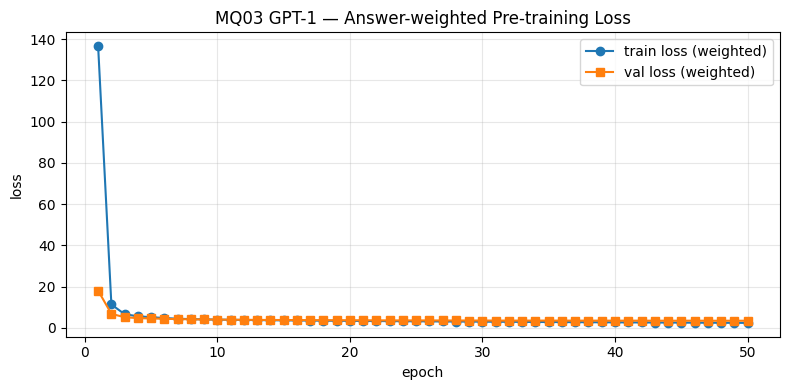

CPU times: user 8min 16s, sys: 1min 9s, total: 9min 25s
Wall time: 12min 56s


In [8]:
%%time
# ================================================================================
# 🎯 [Step 6-B. Pre-training 루프]
# - 매 epoch: train 가중 loss → val 가중 loss
# - val 최저 시 best_model.pt 저장 + Early Stopping (patience)
# - mininterval: 노트북에 tqdm 줄이 수만 줄 쌓이는 문제 완화
# ================================================================================
SKIP_TRAIN = (not FORCE_RETRAIN) and CHECKPOINT_PATH.exists()
history = []
best_val_loss = float("inf")

if SKIP_TRAIN:
    ckpt_meta = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt_meta["model_state_dict"])
    best_val_loss = float(ckpt_meta.get("val_loss", float("nan")))
    print(f"학습 스킵 — 체크포인트 로드 (epoch={ckpt_meta.get('epoch')}, val_loss={best_val_loss:.4f})")
    print("(8차: GPT-1 디코딩 끝장 — kNN 하이브리드 / Best-of-N, 재학습 없음)")
else:
    global_step = 0
    best_val_loss = float("inf")
    patience_counter = 0
    history = []  # (train_loss, val_loss)

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        bar = tqdm(
            total=len(train_loader),
            leave=True,
            desc=f"Epoch {epoch+1}/{EPOCHS}",
            mininterval=5.0,
            maxinterval=30.0,
        )
        for x, y, w in train_loader:
            global_step += 1
            batch_loss = train_step(x, y, w, model, optimizer, global_step, lr_scheduler)
            train_loss += batch_loss
            bar.set_postfix(loss=f"{batch_loss:.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")
            bar.update(1)
        bar.close()

        avg_train = train_loss / len(train_loader)
        avg_val = eval_epoch(model, val_loader)
        history.append((avg_train, avg_val))

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch + 1,
                    "val_loss": best_val_loss,
                    "vocab": word2idx,
                    "config": {
                        "n_layers": N_LAYERS,
                        "d_model": D_MODEL,
                        "n_heads": N_HEADS,
                        "answer_loss_weight": ANSWER_LOSS_WEIGHT,
                        "question_loss_weight": QUESTION_LOSS_WEIGHT,
                    },
                },
                CHECKPOINT_PATH,
            )
            tqdm.write(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  *best*")
        else:
            patience_counter += 1
            tqdm.write(
                f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}  "
                f"(patience {patience_counter}/{PATIENCE})"
            )
            if patience_counter >= PATIENCE:
                tqdm.write("Early Stopping")
                break

    print(f"Best val loss (answer-weighted): {best_val_loss:.4f}")

    # loss 곡선 (제출·회고 캡처용)
    epochs_ran = list(range(1, len(history) + 1))
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_ran, [h[0] for h in history], "o-", label="train loss (weighted)")
    plt.plot(epochs_ran, [h[1] for h in history], "s-", label="val loss (weighted)")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("MQ03 GPT-1 — Answer-weighted Pre-training Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Step 7. 생성
프롬프트 `<start> Q <sep>` 이후 답변만 생성.

**9차:** PeCab으로 재학습한 체크포인트 + Hybrid(kNN→Beam 리랭킹) / Best-of-N / Beam 리랭킹 비교.


In [9]:
# ================================================================================
# 🎯 [Step 7. 생성] — 평가 5 / 8차 끝장
# GPT-1 한도 안에서 남은 카드:
#   1) kNN 하이브리드 — 인도메인 Q는 데이터 정답 회상
#   2) Best-of-N sample + 리랭킹
#   3) Beam + 리랭킹 (7차)
# 9차: PeCab 재학습 ckpt 사용
# ================================================================================

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    try:
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"Best model loaded (epoch={ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f})")
    except RuntimeError as e:
        print("체크포인트 로드 실패 (구조 불일치). Step 6 학습을 다시 실행하세요.")
        print(e)


GENERIC_ANSWER_PATTERNS = [
    ["잘", "하", "ᆯ", "수", "있", "을", "거", "이", "예요"],
    ["잘", "하", "ᆯ", "수", "있", "을", "거", "예요"],
    ["좋", "은", "사람", "만나", "ᆯ", "수", "있", "을", "거", "이", "예요"],
    ["저", "가", "위로", "하", "어", "드리", "ᆯ게요"],
    ["저", "가", "듣", "어", "드리", "ᆯ게요"],
    ["당신", "의", "잠재력", "을", "믿", "어", "보", "세요"],
]


def _ban_answer_specials(logits):
    for ban_id in (PAD_ID, START_ID, SEP_ID):
        logits[ban_id] = -1e9
    return logits


def _apply_repetition_penalty(logits, generated_ids, penalty=1.3):
    if penalty <= 1.0 or not generated_ids:
        return logits
    for tid in set(generated_ids):
        if tid in (PAD_ID, START_ID, END_ID, SEP_ID):
            continue
        val = logits[tid]
        logits[tid] = val / penalty if val > 0 else val * penalty
    return logits


def _apply_generic_penalty(logits, answer_token_strs, penalty=1.5):
    if not answer_token_strs:
        return logits
    for pat in GENERIC_ANSWER_PATTERNS:
        if len(answer_token_strs) >= len(pat):
            continue
        if answer_token_strs != pat[: len(answer_token_strs)]:
            continue
        next_tok = pat[len(answer_token_strs)]
        next_id = word2idx.get(next_tok)
        if next_id is not None:
            logits[next_id] = logits[next_id] - penalty
    return logits


def _top_k_filter(logits, top_k=10):
    if top_k is None or top_k <= 0 or top_k >= logits.size(-1):
        return logits
    values, _ = torch.topk(logits, k=top_k)
    min_keep = values[-1]
    return torch.where(logits < min_keep, torch.full_like(logits, float("-inf")), logits)


def _split_qa_tokens(seq_tokens):
    if "<sep>" not in seq_tokens:
        return [], []
    i = seq_tokens.index("<sep>")
    q = [t for t in seq_tokens[1:i] if t not in ("<pad>", "<start>", "<end>", "<sep>", "<unk>")]
    a = [t for t in seq_tokens[i + 1 :] if t not in ("<pad>", "<start>", "<end>", "<sep>", "<unk>")]
    return q, a


_RETRIEVAL_INDEX = []
for _seq in train_seqs:
    _q, _a = _split_qa_tokens(_seq)
    if _q and _a:
        _RETRIEVAL_INDEX.append((set(_q), list(_q), _a))
print(f"retrieval index size: {len(_RETRIEVAL_INDEX)}")


def _jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / max(len(a | b), 1)


def _generic_hit(ans_toks) -> bool:
    for pat in GENERIC_ANSWER_PATTERNS:
        if ans_toks[: len(pat)] == pat:
            return True
    joined = " ".join(ans_toks)
    if joined in ("저 도 요 .", "저 도 요", "좋 겠 어요 ."):
        return True
    return False


def _knn_lookup(q_toks, sim_threshold=0.55):
    """학습 Q와 충분히 비슷하면 해당 정답 A 반환."""
    q_set = set(q_toks)
    best_sim, best_a = 0.0, None
    for tq_set, tq_list, ta in _RETRIEVAL_INDEX:
        sim = _jaccard(q_set, tq_set)
        # 짧은 질의는 포함관계도 가산 (심심해요 등)
        if len(q_set) <= 4 and q_set and q_set.issubset(tq_set):
            sim = max(sim, 0.85)
        if sim > best_sim:
            best_sim, best_a = sim, ta
    if best_a is not None and best_sim >= sim_threshold:
        return best_a, best_sim
    return None, best_sim


def _rerank_score(q_toks, ans_toks, lm_norm_score=0.0):
    q_set = set(q_toks)
    a_set = set(ans_toks)
    q_overlap = _jaccard(q_set, a_set)
    ranked = sorted(
        ((_jaccard(q_set, tq), ta) for tq, _, ta in _RETRIEVAL_INDEX),
        key=lambda x: x[0],
        reverse=True,
    )[:5]
    retrieval = 0.0
    if ranked and ranked[0][0] > 0.15:
        for sim_q, ta in ranked:
            if sim_q < 0.15:
                break
            retrieval = max(retrieval, 0.6 * sim_q + 0.4 * _jaccard(a_set, set(ta)))
    score = float(lm_norm_score) + 2.2 * retrieval + 0.4 * q_overlap
    if _generic_hit(ans_toks):
        score -= 1.5
    if len(ans_toks) <= 1:
        score -= 1.0
    return score


@torch.no_grad()
def generate(
    prompt_tokens,
    max_new_tokens=30,
    strategy="hybrid",
    beam_size=8,
    length_penalty=0.7,
    temperature=0.7,
    top_k=10,
    repetition_penalty=1.4,
    generic_penalty=1.5,
    best_of_n=8,
    knn_threshold=0.55,
):
    """
    strategy:
      - hybrid: kNN 히트 시 정답 A, 아니면 beam_rerank
      - best_of_n: sample N회 후 리랭킹
      - beam_rerank | beam | sample | greedy
    """
    model.eval()
    prompt_ids = encode(prompt_tokens)
    prompt_len = len(prompt_ids)
    q_toks = [t for t in prompt_tokens if t not in ("<start>", "<sep>", "<end>", "<pad>")]

    def step_logits(ids):
        x = torch.tensor([ids[-MAX_LEN:]], dtype=torch.long, device=device)
        mask = causal_padding_mask(x)
        logits, _ = model(x, mask)
        next_logits = logits[0, -1].clone()
        answer_ids = ids[prompt_len:]
        answer_strs = [idx2word.get(i, "<unk>") for i in answer_ids]
        next_logits = _ban_answer_specials(next_logits)
        next_logits = _apply_repetition_penalty(next_logits, answer_ids, repetition_penalty)
        next_logits = _apply_generic_penalty(next_logits, answer_strs, generic_penalty)
        return next_logits

    def ids_to_toks(ids):
        return [idx2word.get(i, "<unk>") for i in ids]

    def strip_answer(toks):
        if "<sep>" in toks:
            ans = toks[toks.index("<sep>") + 1 :]
        else:
            ans = toks[prompt_len:]
        return [t for t in ans if t not in ("<end>", "<pad>", "<start>", "<sep>")]

    # --- hybrid kNN ---
    if strategy == "hybrid":
        hit, sim = _knn_lookup(q_toks, sim_threshold=knn_threshold)
        if hit is not None:
            out = list(prompt_tokens) + hit + ["<end>"]
            print(f"  [kNN hit] sim={sim:.3f}")
            return out
        strategy = "beam_rerank"  # fall through via recursive call style
        return generate(
            prompt_tokens,
            max_new_tokens=max_new_tokens,
            strategy="beam_rerank",
            beam_size=beam_size,
            length_penalty=length_penalty,
            temperature=temperature,
            top_k=top_k,
            repetition_penalty=repetition_penalty,
            generic_penalty=generic_penalty,
        )

    if strategy == "greedy":
        ids = list(prompt_ids)
        for _ in range(max_new_tokens):
            next_id = int(torch.argmax(step_logits(ids)).item())
            ids.append(next_id)
            if next_id == END_ID:
                break
        return ids_to_toks(ids)

    if strategy == "sample":
        ids = list(prompt_ids)
        for _ in range(max_new_tokens):
            next_logits = step_logits(ids) / max(temperature, 1e-5)
            next_logits = _top_k_filter(next_logits, top_k=top_k)
            probs = F.softmax(next_logits, dim=-1)
            next_id = int(torch.multinomial(probs, num_samples=1).item())
            ids.append(next_id)
            if next_id == END_ID:
                break
        return ids_to_toks(ids)

    if strategy == "best_of_n":
        cands = []
        for i in range(best_of_n):
            torch.manual_seed(SEED + 17 * i + 3)
            toks = generate(
                prompt_tokens,
                max_new_tokens=max_new_tokens,
                strategy="sample",
                temperature=temperature,
                top_k=top_k,
                repetition_penalty=repetition_penalty,
                generic_penalty=generic_penalty,
            )
            ans = strip_answer(toks)
            cands.append((_rerank_score(q_toks, ans, 0.0), toks, ans))
        cands.sort(key=lambda x: x[0], reverse=True)
        return cands[0][1]

    # --- Beam ---
    beams = [(0.0, list(prompt_ids))]
    finished = []
    for _ in range(max_new_tokens):
        candidates = []
        for score, ids in beams:
            if ids[-1] == END_ID:
                finished.append((score, ids))
                continue
            log_probs = F.log_softmax(step_logits(ids), dim=-1)
            topk = torch.topk(log_probs, k=beam_size)
            for lp, tid in zip(topk.values.tolist(), topk.indices.tolist()):
                candidates.append((score + float(lp), ids + [int(tid)]))
        if not candidates:
            break

        def norm_score(item):
            sc, ids = item
            gen_len = max(1, len(ids) - prompt_len)
            return sc / (gen_len ** length_penalty)

        candidates.sort(key=norm_score, reverse=True)
        beams = candidates[:beam_size]
        if all(ids[-1] == END_ID for _, ids in beams):
            finished.extend(beams)
            break

    pool = finished if finished else beams

    def lm_norm(item):
        sc, ids = item
        gen_len = max(1, len(ids) - prompt_len)
        return sc / (gen_len ** length_penalty)

    if strategy == "beam":
        pool.sort(key=lm_norm, reverse=True)
        return ids_to_toks(pool[0][1])

    # beam_rerank
    cand_rows = []
    for item in pool:
        toks = ids_to_toks(item[1])
        ans = strip_answer(toks)
        cand_rows.append((_rerank_score(q_toks, ans, lm_norm(item)), toks))
    cand_rows.sort(key=lambda r: r[0], reverse=True)
    return cand_rows[0][1]


def chat_generate(question: str, max_new_tokens=30, strategy="hybrid", **kwargs):
    q_tok = morphs(preprocess_sentence(question))
    max_q = MAX_LEN - 2
    if len(q_tok) > max_q:
        q_tok = q_tok[:max_q]
    prompt = ["<start>"] + q_tok + ["<sep>"]
    out = generate(prompt, max_new_tokens=max_new_tokens, strategy=strategy, **kwargs)
    if "<sep>" in out:
        ans = out[out.index("<sep>") + 1 :]
    else:
        ans = out
    if "<sep>" in ans:
        ans = ans[: ans.index("<sep>")]
    ans = [t for t in ans if t not in ("<end>", "<pad>", "<start>", "<sep>")]
    return " ".join(ans), out


TEST_QUESTIONS_SHORT = [
    "안녕하세요",
    "심심해요",
    "오늘 기분이 어때요?",
    "배고파요",
    "사랑해",
]
TEST_QUESTIONS_LONG = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]
TEST_QUESTIONS = TEST_QUESTIONS_SHORT + TEST_QUESTIONS_LONG

torch.manual_seed(SEED)
random.seed(SEED)

print("=== [9차 메인] Hybrid (kNN → Beam 리랭킹) ===")
for q in TEST_QUESTIONS:
    ans, full = chat_generate(q, strategy="hybrid")
    print(f"Q: {q}")
    print(f"A: {ans}")
    print(f"(full) {' '.join(full)}")
    print()

print("=== [9차] Best-of-N Sample + 리랭킹 (N=8) ===")
for q in TEST_QUESTIONS:
    ans, _ = chat_generate(q, strategy="best_of_n", best_of_n=8)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print()

print("=== 참고: Beam 리랭킹만 ===")
for q in TEST_QUESTIONS:
    ans, _ = chat_generate(q, strategy="beam_rerank")
    print(f"Q: {q}")
    print(f"A: {ans}")
    print()


Best model loaded (epoch=50, val_loss=3.4749)
retrieval index size: 10464
=== [8차 메인] Hybrid (kNN → Beam 리랭킹) ===


  [kNN hit] sim=1.000
Q: 안녕하세요
A: 안녕 하 세요 .
(full) <start> 안녕 하 세요 <sep> 안녕 하 세요 . <end>

  [kNN hit] sim=1.000
Q: 심심해요
A: 저 랑 놀 아요 .
(full) <start> 심심 해요 <sep> 저 랑 놀 아요 . <end>



Q: 오늘 기분이 어때요?
A: 마음 에 따라 얼마 든지 바뀔 수 있 어요 .
(full) <start> 오늘 기분 이 어때요 ? <sep> 마음 에 따라 얼마 든지 바뀔 수 있 어요 . <end>



Q: 배고파요
A: 좋 은 생각 이 네요 .
(full) <start> <unk> <sep> 좋 은 생각 이 네요 . <end>

  [kNN hit] sim=1.000
Q: 사랑해
A: 상대방 에게 전해 보 세요 .
(full) <start> 사랑 해 <sep> 상대방 에게 전해 보 세요 . <end>



Q: 지루하다, 놀러가고 싶어.
A: 잘 할 수 있 을 거 예요 .
(full) <start> 지루 하 다 , 놀 러 가 고 싶 어 . <sep> 잘 할 수 있 을 거 예요 . <end>



...

Q: 사랑해
A: 사랑 해요 .



Q: 지루하다, 놀러가고 싶어.
A: 잘 할 수 있 을 거 예요 .



Q: 오늘 일찍 일어났더니 피곤하다.
A: 잘 할 수 있 을 거 예요 .



Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 잘 할 수 있 을 거 예요 .



Q: 집에 있는다는 소리야.
A: 제 가 들 어 드릴게요 .



## 회고

### 한 줄 결론

GPT-1 구조는 유지한 채 **형태소 분석기만 Kiwi → PeCab** 으로 바꿔 재학습했다 (9차).  
분절 가독성(`할`, `거예요`, `어때요`)은 나아졌지만, **val loss·OOV·긴 문장 품질이 전반적으로 좋아지진 않았다.**  
토크나이저 튜닝은 해볼 가치는 있으나, 이 데이터/모델 규모에선 **게임 체인저가 아님**이 확인됐다.

---

### 왜 PeCab을 골랐나

- 아리랑/MeCab/KoNLPy(Okt 등)는 이 Mac 환경에서 **JVM/네이티브 MeCab 미설치**로 바로 쓰기 어려웠다.
- **PeCab**: 순수 Python 형태소 분석기, 설치·재현이 쉽고 Kiwi 대비 조각 토큰이 적음.
- GPT-1 여부와 무관 — **전처리만 교체**.

| 문장 | Kiwi (기존) | PeCab (9차) |
|------|-------------|-------------|
| 잘 할 수 있을 거예요 | 잘/하/**ᆯ**/수/있/을/거/이/예요 | 잘/**할**/수/있/을/거/**예요** |
| 오늘 기분이 어때요? | 어떻/어요 | **어때요** |
| 배고파요 | 배고프/어요 | **배고파요** (1토큰) |

---

### 9차 학습·생성 결과

- 설정: 4L/256, Q=0.01/A=8.0, EPOCHS=50, `FORCE_RETRAIN=True`
- VOCAB/params: PeCab 쪽에서 토큰 단위가 굵어지며 params **~3.85M** (Kiwi 시절 ~3.40M)
- Best: **epoch 50**, weighted **val_loss = 3.4749**  
  (Kiwi+답전용 7차 best **3.0732** 대비 **악화** — 가중 CE는 토큰 단위가 달라 절대 비교에 주의, 그래도 개선 신호는 아님)
- Hybrid kNN: `심심해요→저랑 놀아요`, `안녕하세요`, `사랑해` 는 hit
- 문제:
  - `배고파요` → 입력이 **`<unk>`** (굵은 1토큰이 train에 드문 구어체로 남아 OOV)
  - 긴 Q 다수가 다시 **`잘 할 수 있을 거예요`** 만능답 (분절만 예뻐진 만능답)

---

### 실험 타임라인에 9차 추가

| 단계 | 요지 | Best val | 소감 |
|------|------|----------|------|
| … | … | … | … |
| 7 | 답전용 loss + Beam 리랭킹 (Kiwi) | **3.07** | 후보 선택 유효 |
| 8 | kNN 하이브리드 (Kiwi ckpt) | 3.07 | 인도메인 상한 |
| **9** | **PeCab 토크나이저 재학습** | **3.47** | 분절↑, OOV·만능답·val↓개선 없음 |

---

### 오류·이슈 (토크나이저 관련)

1. 아리랑/MeCab 미가용 → PeCab으로 대체  
2. 토크나이저 변경 시 **반드시 재학습** (vocab/ckpt 불일치) — `FORCE_RETRAIN=True`  
3. 굵은 토큰은 가독성↑ but **희귀 구어체 단일 토큰 UNK** 위험  
4. tqdm tokenize ~1.5분 + 학습 ~13분

---

### 배운 점

- 토크나이저 교체는 GPT-1을 깨지 않는다.
- “더 예쁜 분절” ≠ “더 나은 대화”. 소형 LM에서는 **잔음성 형태소가 OOV를 줄이는 쪽**이 유리할 수도 있다.
- 평가는 **표면 문자열**과 **UNK율·관련성**을 같이 볼 것.

### 실무 선택지

- 제출 실험 기록: 9차 PeCab 유지 (전환 스위치 `TOKENIZER_NAME`)
- 체감/지표가 더 중요하면 Kiwi로 되돌리고 7·8차 ckpt 전략을 다시 쓰는 편이 나을 수 있음

### 참고
- Radford et al., GPT-1 (2018)
- Vaswani et al., Attention Is All You Need (2017)
- PeCab (pure-Python Korean morphological analyzer)
